# Nome: Neivan Júnior Alves Costa
# Matrícula: aluno especial

## Import all packages need in the cell below

In [3]:
using LinearAlgebra
using ForwardDiff
using Optim
using NLsolve
using Plots
using JuMP
using HiGHS

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

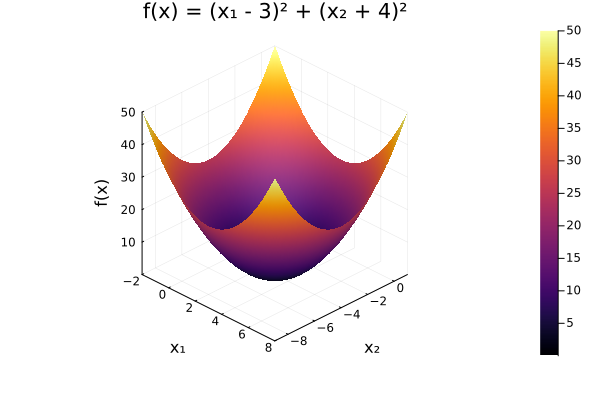

In [5]:
f_fonc(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

x1_grid = range(-2, 8, length=100)
x2_grid = range(-9, 1, length=100)
Z = [f_fonc(x1, x2) for x2 in x2_grid, x1 in x1_grid]

surface(x1_grid, x2_grid, Z,
    xlabel="x₁", ylabel="x₂", zlabel="f(x)",
    title="f(x) = (x₁ - 3)² + (x₂ + 4)²",
    camera=(45, 30))


## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [96]:
z(x) = (x[1] - 1)^4 + (x[2] - 2)^4
grad_z(x) = ForwardDiff.gradient(z, x)

# 1) Mínimo usando Optim.jl
resultado_optim = optimize(z, [0.0, 0.0], BFGS(); autodiff=:forward)

println("Mínimo usando Optim.jl")
println("x* = ", Optim.minimizer(resultado_optim))
println("z(x*) = ", Optim.minimum(resultado_optim))

# 2) FONC usando NLsolve.jl: ∇z(x) = 0
resultado_nlsolve = nlsolve(x -> grad_z(x), [0.0, 0.0])

println("\nSolução da FONC usando NLsolve.jl")
println("x* = ", resultado_nlsolve.zero)
println("∇z(x*) = ", grad_z(resultado_nlsolve.zero))


Mínimo usando Optim.jl
x* = [0.9993315593011184, 2.000722800668069]
z(x*) = 4.725862238266366e-13

Solução da FONC usando NLsolve.jl
x* = [0.9995401607802424, 1.9990803216092672]
∇z(x*) = [-3.8893588948535965e-10, -3.111486620757018e-9]


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

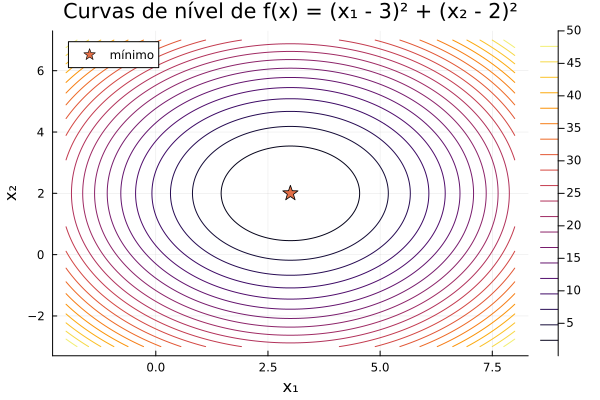

In [98]:
f_level(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

x1_grid = range(-2, 8, length=150)
x2_grid = range(-3, 7, length=150)
Z = [f_level(x1, x2) for x2 in x2_grid, x1 in x1_grid]

contour(x1_grid, x2_grid, Z,
    levels=20,
    xlabel="x₁", ylabel="x₂",
    title="Curvas de nível de f(x) = (x₁ - 3)² + (x₂ - 2)²",
    label="")
scatter!([3], [2], marker=:star, markersize=8, label="mínimo")


Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [100]:
function gradient_descent(f, grad_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=10_000)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        if norm(g) <= tol
            return x, k-1, hist
        end

        Δx = -g
        t = 1.0

        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

function newton_method(f, grad_f, hess_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=100)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)
        Δx = -H \ g
        λ2 = dot(g, H \ g)

        if λ2/2 <= tol
            return x, k-1, hist
        end

        t = 1.0
        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

f1(x) = (x[1] - 3)^2 + (x[2] - 2)^2
grad_f1(x) = ForwardDiff.gradient(f1, x)
hess_f1(x) = ForwardDiff.hessian(f1, x)

x0 = [1.0, 1.0]

x_gd, it_gd, hist_gd = gradient_descent(f1, grad_f1, x0)
x_nt, it_nt, hist_nt = newton_method(f1, grad_f1, hess_f1, x0)

println("Gradiente descendente:")
println("x* = ", x_gd)
println("f(x*) = ", f1(x_gd))
println("iterações = ", it_gd)

println("\nNewton:")
println("x* = ", x_nt)
println("f(x*) = ", f1(x_nt))
println("iterações = ", it_nt)


Gradiente descendente:
x* = [3.0, 2.0]
f(x*) = 0.0
iterações = 1

Newton:
x* = [3.0, 2.0]
f(x*) = 0.0
iterações = 1


Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [102]:
function gradient_descent(f, grad_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=10_000)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        if norm(g) <= tol
            return x, k-1, hist
        end

        Δx = -g
        t = 1.0

        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

function newton_method(f, grad_f, hess_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=100)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)
        Δx = -H \ g
        λ2 = dot(g, H \ g)

        if λ2/2 <= tol
            return x, k-1, hist
        end

        t = 1.0
        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

f2(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2
grad_f2(x) = ForwardDiff.gradient(f2, x)
hess_f2(x) = ForwardDiff.hessian(f2, x)

x0 = [1.0, 1.0]

x_gd, it_gd, hist_gd = gradient_descent(f2, grad_f2, x0)
x_nt, it_nt, hist_nt = newton_method(f2, grad_f2, hess_f2, x0)

println("Gradiente descendente:")
println("x* = ", x_gd)
println("f(x*) = ", f2(x_gd))
println("iterações = ", it_gd)

println("\nNewton:")
println("x* = ", x_nt)
println("f(x*) = ", f2(x_nt))
println("iterações = ", it_nt)


Gradiente descendente:
x* = [2.999999864059845, 1.999998572628371]
f(x*) = 4.25957679170995e-12
iterações = 29

Newton:
x* = [3.0, 2.0]
f(x*) = 0.0
iterações = 1


Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [15]:
function gradient_descent(f, grad_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=10_000)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        if norm(g) <= tol
            return x, k-1, hist
        end

        Δx = -g
        t = 1.0

        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

function newton_method(f, grad_f, hess_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=100)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)
        Δx = -H \ g
        λ2 = dot(g, H \ g)

        if λ2/2 <= tol
            return x, k-1, hist
        end

        t = 1.0
        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

f3(x) = x[1]^2 + x[2]^2
grad_f3(x) = ForwardDiff.gradient(f3, x)
hess_f3(x) = ForwardDiff.hessian(f3, x)

x0 = [-2.0, 2.0]

x_gd, it_gd, hist_gd = gradient_descent(f3, grad_f3, x0)
x_nt, it_nt, hist_nt = newton_method(f3, grad_f3, hess_f3, x0)

println("Gradiente descendente:")
println("x* = ", x_gd)
println("f(x*) = ", f3(x_gd))
println("iterações = ", it_gd)

println("\nNewton:")
println("x* = ", x_nt)
println("f(x*) = ", f3(x_nt))
println("iterações = ", it_nt)


Gradiente descendente:
x* = [0.0, 0.0]
f(x*) = 0.0
iterações = 1

Newton:
x* = [0.0, 0.0]
f(x*) = 0.0
iterações = 1


Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [17]:
function gradient_descent(f, grad_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=10_000)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        if norm(g) <= tol
            return x, k-1, hist
        end

        Δx = -g
        t = 1.0

        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

function newton_method(f, grad_f, hess_f, x0; α=0.4, β=0.5, tol=1e-5, max_iter=100)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)
        Δx = -H \ g
        λ2 = dot(g, H \ g)

        if λ2/2 <= tol
            return x, k-1, hist
        end

        t = 1.0
        while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
            t *= β
        end

        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, max_iter, hist
end

f4(x) = x[1]^2 + 100*x[2]^2
grad_f4(x) = ForwardDiff.gradient(f4, x)
hess_f4(x) = ForwardDiff.hessian(f4, x)

x0 = [-2.0, 2.0]

x_gd, it_gd, hist_gd = gradient_descent(f4, grad_f4, x0)
x_nt, it_nt, hist_nt = newton_method(f4, grad_f4, hess_f4, x0)

println("Gradiente descendente:")
println("x* = ", x_gd)
println("f(x*) = ", f4(x_gd))
println("iterações = ", it_gd)

println("\nNewton:")
println("x* = ", x_nt)
println("f(x*) = ", f4(x_nt))
println("iterações = ", it_nt)


Gradiente descendente:
x* = [-4.0437239972265555e-6, -2.0151199257165205e-8]
f(x*) = 1.639231084889611e-11
iterações = 554

Newton:
x* = [0.0, 0.0]
f(x*) = 0.0
iterações = 1


For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [20]:
function f_nonlin(x)
    x1, x2, x3 = x
    return x3*log(exp(x1/x3) + exp(x2/x3)) + (x3 - 2)^2 + exp(1/(x1 + x2))
end

function dominio(x)
    return (x[1] + x[2] > 0) && (x[3] > 0) && all(isfinite, x)
end

println("f_nonlin([3,4,5]) = ", f_nonlin([3.0, 4.0, 5.0]))
println("Está no domínio? ", dominio([3.0, 4.0, 5.0]))


f_nonlin([3,4,5]) = 17.144259341803068
Está no domínio? true


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [23]:
function grad_f_nonlin(x)
    return ForwardDiff.gradient(f_nonlin, x)
end

println("∇f(x0) em [3,4,5] = ", grad_f_nonlin([3.0, 4.0, 5.0]))


∇f(x0) em [3,4,5] = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [25]:
α = 0.4
β = 0.5
eps = 1e-5
println("α = $α, β = $β, eps = $eps")


α = 0.4, β = 0.5, eps = 1.0e-5


Start Point: [3.0, 4.0, 5.0]

In [27]:
x0 = [3.0, 4.0, 5.0]
println("x0 = ", x0)


x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [29]:
function garantir_dominio(x, Δx; β=0.5)
    t = 1.0

    while !dominio(x + t*Δx)
        t *= β
    end

    return t
end

Δx = -grad_f_nonlin(x0)
t_dom = garantir_dominio(x0, Δx; β=β)

println("Direção Δx = -∇f(x0) = ", Δx)
println("Passo após garantir domínio = ", t_dom)
println("Novo ponto = ", x0 + t_dom*Δx)
println("Está no domínio? ", dominio(x0 + t_dom*Δx))


Direção Δx = -∇f(x0) = [-0.42662385993456065, -0.5262918545595165, -6.688172069919096]
Passo após garantir domínio = 0.5
Novo ponto = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [31]:
function backtracking_line_search(f, grad_f, dominio, x, Δx; α=0.4, β=0.5)
    t = 1.0
    g = grad_f(x)

    while !dominio(x + t*Δx)
        t *= β
    end

    while f(x + t*Δx) > f(x) + α*t*dot(g, Δx)
        t *= β
    end

    return t
end

t_bt = backtracking_line_search(f_nonlin, grad_f_nonlin, dominio, x0, Δx; α=α, β=β)
println("Passo pelo backtracking = ", t_bt)
println("Novo ponto = ", x0 + t_bt*Δx)


Passo pelo backtracking = 0.5
Novo ponto = [2.78668807003272, 3.7368540727202415, 1.655913965040452]


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [33]:
function gradient_descent_nonlin(x0; α=0.4, β=0.5, eps=1e-5, max_iter=10_000)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)

        if norm(g) <= eps
            return x, f_nonlin(x), k-1, hist
        end

        Δx = -g
        t = backtracking_line_search(f_nonlin, grad_f_nonlin, dominio, x, Δx; α=α, β=β)
        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, f_nonlin(x), max_iter, hist
end

x_gd, f_gd, it_gd, hist_gd = gradient_descent_nonlin(x0; α=α, β=β, eps=eps)

println("Gradiente descendente para função não linear")
println("x* = ", x_gd)
println("f(x*) = ", f_gd)
println("∇f(x*) = ", grad_f_nonlin(x_gd))
println("||∇f(x*)|| = ", norm(grad_f_nonlin(x_gd)))
println("iterações = ", it_gd)


Gradiente descendente para função não linear
x* = [0.9261872701983406, 0.9262296480441213, 1.6534264097600673]
f(x*) = 3.908113786397637
∇f(x*) = [-6.40758107955941e-6, 6.407578255207547e-6, -2.034150625718212e-12]
||∇f(x*)|| = 9.06168606760025e-6
iterações = 30


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [35]:
function hess_f_nonlin(x)
    return ForwardDiff.hessian(f_nonlin, x)
end

println("Hessiana em x0:")
display(hess_f_nonlin(x0))


Hessiana em x0:


3×3 Matrix{Float64}:
  0.0567101   -0.0422965    0.00990066
 -0.0422965    0.0567101   -0.00990066
  0.00990066  -0.00990066   2.00198

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [104]:
α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]
println("Parâmetros definidos.")


Parâmetros definidos.


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [39]:
function passo_newton(x)
    g = grad_f_nonlin(x)
    H = hess_f_nonlin(x)
    return -H \ g
end

Δx_nt = passo_newton(x0)
t_dom_nt = garantir_dominio(x0, Δx_nt; β=β)

println("Direção de Newton = ", Δx_nt)
println("Passo após garantir domínio = ", t_dom_nt)
println("Novo ponto = ", x0 + t_dom_nt*Δx_nt)


Direção de Newton = [-32.21798367184796, -33.8944775714916, -3.3490694346907963]
Passo após garantir domínio = 0.0625
Novo ponto = [0.9863760205095025, 1.881595151781775, 4.790683160331826]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [41]:
t_bt_nt = backtracking_line_search(f_nonlin, grad_f_nonlin, dominio, x0, Δx_nt; α=α, β=β)
println("Passo de Newton com backtracking = ", t_bt_nt)
println("Novo ponto = ", x0 + t_bt_nt*Δx_nt)


Passo de Newton com backtracking = 0.0625
Novo ponto = [0.9863760205095025, 1.881595151781775, 4.790683160331826]


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [44]:
function newton_nonlin(x0; α=0.4, β=0.5, eps=1e-5, max_iter=100)
    x = copy(x0)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)
        H = hess_f_nonlin(x)
        Δx = -H \ g
        λ2 = dot(g, H \ g)

        if λ2/2 <= eps
            return x, f_nonlin(x), k-1, hist
        end

        t = backtracking_line_search(f_nonlin, grad_f_nonlin, dominio, x, Δx; α=α, β=β)
        x = x + t*Δx
        push!(hist, copy(x))
    end

    return x, f_nonlin(x), max_iter, hist
end

x_nt, f_nt, it_nt, hist_nt = newton_nonlin(x0; α=α, β=β, eps=eps)

println("Método de Newton")
println("x* = ", x_nt)
println("f(x*) = ", f_nt)
println("∇f(x*) = ", grad_f_nonlin(x_nt))
println("||∇f(x*)|| = ", norm(grad_f_nonlin(x_nt)))
println("iterações = ", it_nt)


Método de Newton
x* = [0.9259801588949454, 0.9260041301052006, 1.653301625909102]
f(x*) = 3.9081138660512487
∇f(x*) = [-0.00030034215272334297, -0.00029309265575339083, -0.00024956764812811283]
||∇f(x*)|| = 0.00048825477422270546
iterações = 4


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [47]:
println("Função, gradiente e domínio prontos para BFGS.")
println("f(x0) = ", f_nonlin(x0))
println("grad_f_nonlin(x0) = ", grad_f_nonlin(x0))


Função, gradiente e domínio prontos para BFGS.
f(x0) = 17.144259341803068
grad_f_nonlin(x0) = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [49]:
α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]
H0 = Matrix(I, length(x0), length(x0))

println("x0 = ", x0)
println("H0 = ")
display(H0)


x0 = [3.0, 4.0, 5.0]
H0 = 


3×3 Matrix{Bool}:
 1  0  0
 0  1  0
 0  0  1

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [51]:
function garantir_dominio_bfgs(x, p; β=0.5)
    t = 1.0

    while !dominio(x + t*p)
        t *= β
    end

    return t
end

p0 = -H0 * grad_f_nonlin(x0)
t_bfgs_dom = garantir_dominio_bfgs(x0, p0; β=β)

println("Direção inicial BFGS = ", p0)
println("Passo após garantir domínio = ", t_bfgs_dom)
println("Novo ponto = ", x0 + t_bfgs_dom*p0)


Direção inicial BFGS = [-0.42662385993456065, -0.5262918545595165, -6.688172069919096]
Passo após garantir domínio = 0.5
Novo ponto = [2.78668807003272, 3.7368540727202415, 1.655913965040452]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [54]:
function backtracking_bfgs(x, p; α=0.4, β=0.5)
    t = garantir_dominio_bfgs(x, p; β=β)
    g = grad_f_nonlin(x)

    while f_nonlin(x + t*p) > f_nonlin(x) + α*t*dot(g, p)
        t *= β
    end

    return t
end

t_bfgs = backtracking_bfgs(x0, p0; α=α, β=β)
println("Passo BFGS com backtracking = ", t_bfgs)
println("Novo ponto = ", x0 + t_bfgs*p0)


Passo BFGS com backtracking = 0.5
Novo ponto = [2.78668807003272, 3.7368540727202415, 1.655913965040452]


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [56]:
function bfgs_nonlin(x0; α=0.4, β=0.5, eps=1e-5, max_iter=1_000)
    x = copy(x0)
    n = length(x)
    H = Matrix(I, n, n)
    hist = [copy(x)]

    for k in 1:max_iter
        g = grad_f_nonlin(x)

        if norm(g) <= eps
            return x, f_nonlin(x), k-1, hist
        end

        p = -H * g
        t = backtracking_bfgs(x, p; α=α, β=β)

        x_new = x + t*p
        g_new = grad_f_nonlin(x_new)

        s = x_new - x
        y = g_new - g
        ys = dot(y, s)

        if ys > 1e-8
            ρ = 1/ys
            V = Matrix(I, n, n) - ρ*s*y'
            H = V*H*V' + ρ*(s*s')
        else
          
            H = Matrix(I, n, n)
        end

        x = x_new
        push!(hist, copy(x))
    end

    return x, f_nonlin(x), max_iter, hist
end

x_bfgs, f_bfgs, it_bfgs, hist_bfgs = bfgs_nonlin(x0; α=α, β=β, eps=eps)

println("Método BFGS")
println("x* = ", x_bfgs)
println("f(x*) = ", f_bfgs)
println("∇f(x*) = ", grad_f_nonlin(x_bfgs))
println("||∇f(x*)|| = ", norm(grad_f_nonlin(x_bfgs)))
println("iterações = ", it_bfgs)


Método BFGS
x* = [0.9262108201941383, 0.9262107344070644, 1.6534258875113628]
f(x*) = 3.9081137862695083
∇f(x*) = [3.191393537715914e-6, 3.1654513183432265e-6, -1.0444173293988612e-6]
||∇f(x*)|| = 4.614746181462684e-6
iterações = 11


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [60]:
# linear state-space model
A = [
    0.2681   -0.00338   -0.00728;
    9.703     0.3279   -25.44;
    0.0       0.0        1.0
]

B = [
    -0.00537    0.1655;
     1.297     97.91;
     0.0       -6.637
]

C = [
    1.0  0.0  0.0;
    0.0  1.0  0.0;
    0.0  0.0  1.0
]

# time horizon
N = 3

nx = 3
nu = 2
ny = 3

# initial condition
x0_cstr = [-0.03, 0.0, 0.3]

# bounds for state and input
xmin = [-0.05, -5.0, -0.5]
xmax = [ 0.05,  5.0,  0.5]

umin = [-10.0, -0.05]
umax = [ 10.0,  0.05]

println("Matrizes e parâmetros do CSTR definidos.")


Matrizes e parâmetros do CSTR definidos.


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [62]:
modelo = Model(HiGHS.Optimizer)
set_silent(modelo)

@variable(modelo, x[1:nx, 0:N])
@variable(modelo, u[1:nu, 0:N-1])
@variable(modelo, y[1:ny, 0:N])
@variable(modelo, z1[0:N] >= 0)
@variable(modelo, z2[0:N] >= 0)

# Condição inicial
@constraint(modelo, [i=1:nx], x[i,0] == x0_cstr[i])

# Dinâmica: x(k+1) = A*x(k) + B*u(k)
@constraint(modelo, [k=0:N-1, i=1:nx],
    x[i,k+1] ==
    sum(A[i,j] * x[j,k] for j=1:nx) +
    sum(B[i,j] * u[j,k] for j=1:nu)
)

# Saída: y(k) = C*x(k)
@constraint(modelo, [k=0:N, i=1:ny],
    y[i,k] == sum(C[i,j] * x[j,k] for j=1:nx)
)

# Limites dos estados
@constraint(modelo, [k=0:N, i=1:nx], x[i,k] >= xmin[i])
@constraint(modelo, [k=0:N, i=1:nx], x[i,k] <= xmax[i])

# Limites das entradas
@constraint(modelo, [k=0:N-1, j=1:nu], u[j,k] >= umin[j])
@constraint(modelo, [k=0:N-1, j=1:nu], u[j,k] <= umax[j])

# Variáveis auxiliares para valor absoluto:
# z1(k) >= |y1(k)| e z2(k) >= |y3(k)|
@constraint(modelo, [k=0:N], y[1,k] <= z1[k])
@constraint(modelo, [k=0:N], -y[1,k] <= z1[k])

@constraint(modelo, [k=0:N], y[3,k] <= z2[k])
@constraint(modelo, [k=0:N], -y[3,k] <= z2[k])

# Função objetivo
@objective(modelo, Min, sum(z1[k] + z2[k] for k=0:N))

println("Modelo de otimização criado.")


Modelo de otimização criado.


## Solve and Postprocess

Status da otimização = OPTIMAL
Valor objetivo = 0.32999999999999996
Estados x(k):


3×4 Matrix{Float64}:
 -0.03  -0.0      -0.0      -0.0
 -0.0   -4.16073   2.03236  -0.992727
  0.3   -0.0      -0.0      -0.0

Entradas u(k):


2×3 Matrix{Float64}:
 -0.511399    2.61886  -1.27921
  0.0452011  -0.0      -0.0

Saídas y(k):


3×4 Matrix{Float64}:
 -0.03  -0.0      -0.0      -0.0
 -0.0   -4.16073   2.03236  -0.992727
  0.3   -0.0      -0.0      -0.0

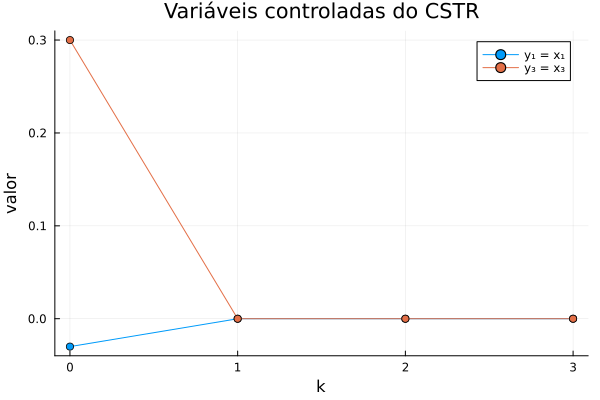

In [64]:
optimize!(modelo)

println("Status da otimização = ", termination_status(modelo))
println("Valor objetivo = ", objective_value(modelo))

X = Matrix(value.(x))
U = Matrix(value.(u))
Y = Matrix(value.(y))

println("Estados x(k):")
display(X)

println("Entradas u(k):")
display(U)

println("Saídas y(k):")
display(Y)

k_estado = 0:N
k_entrada = 0:N-1

plot(k_estado, Y[1, :],
    marker=:circle,
    label="y₁ = x₁",
    xlabel="k",
    ylabel="valor",
    title="Variáveis controladas do CSTR"
)
plot!(k_estado, Y[3, :],
    marker=:circle,
    label="y₃ = x₃"
)


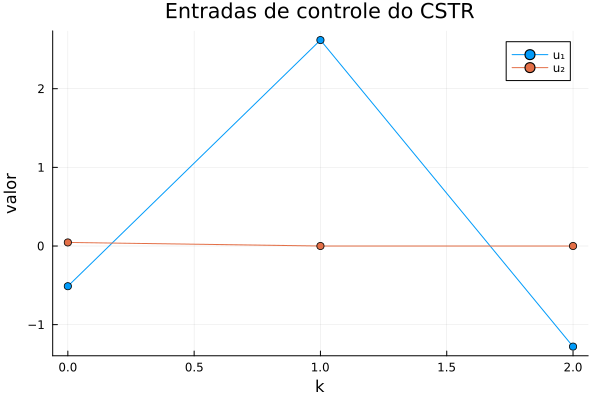

In [65]:
plot(k_entrada, U[1, :],
    marker=:circle,
    label="u₁",
    xlabel="k",
    ylabel="valor",
    title="Entradas de controle do CSTR"
)
plot!(k_entrada, U[2, :],
    marker=:circle,
    label="u₂"
)
